**Clustering K-Means (non supervisé)**
Regrouper les événements en profils similaires selon leurs caractéristiques
numériques (`GoldsteinScale`, `AvgTone`, `NumMentions`, `NumSources`).

Objectif : découvrir des patterns que les catégories CAMEO ne capturent pas.

Le modèle final est sauvegardé dans le dossier `models/`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_PATH = Path('..') / 'data' / 'processed' / 'events_cleaned.csv'
MODEL_DIR = Path('..') / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Chargement des données depuis : {DATA_PATH}')
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'✅ Events chargé  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Chargement des données depuis : ..\data\processed\events_cleaned.csv
✅ Events chargé  : 27,317 lignes × 46 colonnes


## Préparation des données
Nous utilisons les mêmes features que dans le notebook principal : `GoldsteinScale`, `AvgTone`, `NumMentions`, `NumSources`.

In [ ]:
ML_FEATURES = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources']
ml_cols = ML_FEATURES + ['QuadClass', 'QuadLabel']
ml_cols_ok = [c for c in ml_cols if c in df.columns]

df_ml = df[ml_cols_ok].dropna(subset=ML_FEATURES).copy()
q99 = df_ml['NumMentions'].quantile(0.99)
df_ml = df_ml[df_ml['NumMentions'] <= q99]

print(f'Dataset ML : {len(df_ml):,} événements')
print('Features utilisées :', ML_FEATURES)
print('\nDistribution QuadClass :')
if 'QuadLabel' in df_ml.columns:
    print(df_ml['QuadLabel'].value_counts().to_string())
else:
    print('QuadLabel non disponible dans le dataset.')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[ML_FEATURES])
print('\n✅ Features normalisées (StandardScaler)')

Dataset ML : 27,268 événements
Features utilisées : ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources']

Distribution QuadClass :
QuadLabel non disponible dans le dataset.

✅ Features normalisées (StandardScaler)


## Sélection du nombre de clusters
Nous utilisons la méthode du coude et le score de silhouette pour choisir le meilleur `k`.

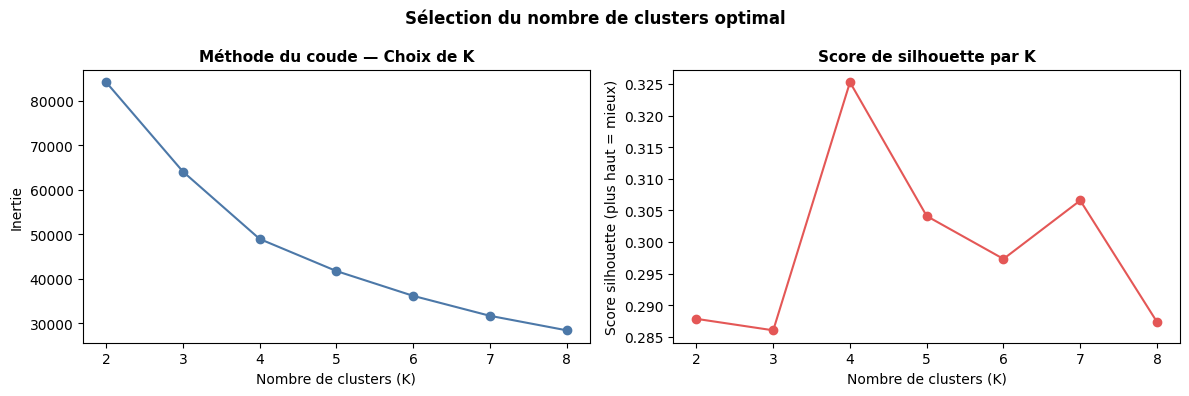

K optimal (silhouette max) : 4
Score silhouette           : 0.325


In [ ]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k, sample_size=min(2000, len(X_scaled))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='#4C78A8')
axes[0].set_title('Méthode du coude — Choix de K', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')

axes[1].plot(list(K_range), silhouettes, marker='o', color='#E45756')
axes[1].set_title('Score de silhouette par K', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score silhouette (plus haut = mieux)')

plt.suptitle('Sélection du nombre de clusters optimal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'K optimal (silhouette max) : {best_k}')
print(f'Score silhouette           : {max(silhouettes):.3f}')

## Entraînement final du modèle K-Means
Nous entraînons le modèle final avec `best_k` et examinons les profils de cluster.

Profil moyen des clusters :
         GoldsteinScale  AvgTone  NumMentions  NumSources
cluster                                                  
0                 2.905    0.295        2.901       1.000
1                 2.428   -0.288       10.092       1.000
2                -0.485   -2.425        9.038       2.181
3                -5.063   -5.412        4.852       1.000


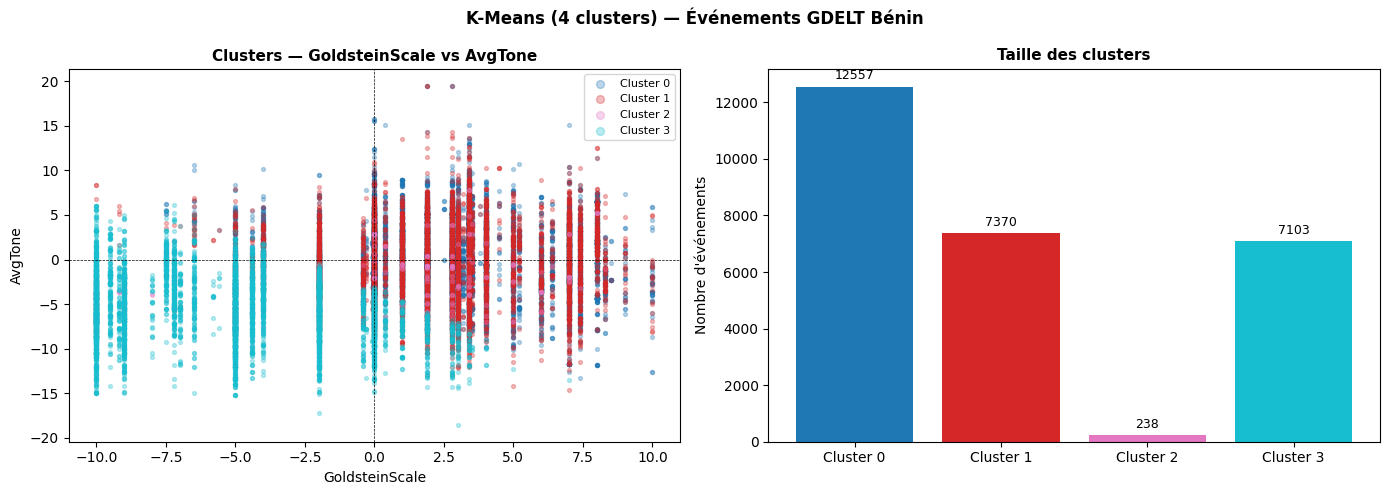


Interprétation des clusters :
   Cluster 0 → coopératif/positif (Goldstein=2.90, AvgTone=0.29)
   Cluster 1 → mixte (Goldstein=2.43, AvgTone=-0.29)
   Cluster 2 → conflictuel/négatif (Goldstein=-0.48, AvgTone=-2.42)
   Cluster 3 → conflictuel/négatif (Goldstein=-5.06, AvgTone=-5.41)


In [ ]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_ml['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_profile = (
    df_ml.groupby('cluster')[ML_FEATURES]
    .mean()
    .round(3)
)
print('Profil moyen des clusters :')
print(cluster_profile.to_string())

if 'QuadLabel' in df_ml.columns:
    cluster_quad = (
        df_ml.groupby(['cluster', 'QuadLabel'])
        .size()
        .unstack(fill_value=0)
    )
    print('\nRépartition QuadClass par cluster :')
    print(cluster_quad.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_cluster = plt.cm.tab10(np.linspace(0, 1, best_k))
for i in range(best_k):
    mask = df_ml['cluster'] == i
    axes[0].scatter(df_ml.loc[mask, 'GoldsteinScale'],
                    df_ml.loc[mask, 'AvgTone'],
                    s=8, alpha=0.3, color=colors_cluster[i],
                    label=f'Cluster {i}')
axes[0].set_xlabel('GoldsteinScale')
axes[0].set_ylabel('AvgTone')
axes[0].set_title('Clusters — GoldsteinScale vs AvgTone', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.5)

cluster_sizes = df_ml['cluster'].value_counts().sort_index()
axes[1].bar([f'Cluster {i}' for i in cluster_sizes.index],
            cluster_sizes.values, color=colors_cluster[:len(cluster_sizes)])
axes[1].set_title('Taille des clusters', fontsize=11, fontweight='bold')
axes[1].set_ylabel("Nombre d'événements")
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)

plt.suptitle(f'K-Means ({best_k} clusters) — Événements GDELT Bénin',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterprétation des clusters :')
for i, row in cluster_profile.iterrows():
    gs, tone = row['GoldsteinScale'], row['AvgTone']
    profil = ('coopératif/positif' if gs > 0 and tone > 0
              else 'conflictuel/négatif' if gs < 0 and tone < 0
              else 'mixte')
    print(f'   Cluster {i} → {profil} (Goldstein={gs:.2f}, AvgTone={tone:.2f})')

## Sauvegarde du modèle
Le modèle K-Means final et le scaler sont sauvegardés dans le dossier `models/` pour réutilisation future.

In [ ]:
MODEL_SUBDIR = MODEL_DIR / 'clustering'
MODEL_SUBDIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_SUBDIR / 'kmeans_model.pkl'
SCALER_PATH = MODEL_SUBDIR / 'kmeans_scaler.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(kmeans_final, f)
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

print(f'Modèle sauvegardé : {MODEL_PATH}')
print(f'Scaler sauvegardé : {SCALER_PATH}')

Modèle sauvegardé : ..\models\clustering\kmeans_model.pkl
Scaler sauvegardé : ..\models\clustering\kmeans_scaler.pkl
